## **Multiclass Classification**
DOMANDA: DOBBIAMO CONSIDERARE ANCHE CLASSE 'NON MUTATED'?????

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [ ]:
mutation = pd.read_csv('OmicsSomaticMutations.csv')
mutation = mutation[mutation.HugoSymbol == 'TP53'] # filter for TP53 mutations


/var/folders/bm/yxd_5px52t5d6m_z9t3mp9400000gn/T/ipykernel_5447/1288859853.py:1: DtypeWarning: Columns (22,50,56,57,58,59,61) have mixed types. Specify dtype option on import or set low_memory=False.
  mutation = pd.read_csv('OmicsSomaticMutations.csv')


In [ ]:
mutation_subset = mutation[['ModelID', 'VariantType']]


In [ ]:
expression = pd.read_csv('OmicsExpressionProteinCodingGenesTPMLogp1.csv')
expression = expression.rename(columns={'Unnamed: 0': 'ModelID'})


In [ ]:
merged_df = pd.merge(expression, mutation_subset, on='ModelID', how='inner')

In [ ]:
merged_df

,ModelID,TSPAN6 (7105),TNMD (64102),DPM1 (8813),SCYL3 (57147),C1orf112 (55732),FGR (2268),CFH (3075),FUCA2 (2519),GCLC (2729),...,H3C3 (8352),AC098582.1 (8916),DUS4L-BCAP29 (115253422),C8orf44-SGK3 (100533105),ELOA3B (728929),NPBWR1 (2831),ELOA3D (100506888),ELOA3 (162699),CDR1 (1038),VariantType
0,ACH-001113,4.331992,0.0,7.364660,2.792855,4.471187,0.028569,1.226509,3.044394,6.500005,...,0.189034,0.201634,2.130931,0.555816,0.000000,0.275007,0.000000,0.000000,0.000000,SNV
1,ACH-001339,3.150560,0.0,7.379118,2.333424,4.228049,0.056584,1.310340,6.687201,3.682573,...,1.097611,0.831877,2.946731,0.475085,0.000000,0.084064,0.000000,0.000000,0.042644,SNV
2,ACH-000233,0.056584,0.0,6.094236,3.971773,3.731183,0.028569,6.093602,3.033863,3.422233,...,1.244887,0.641546,3.157044,0.226509,0.000000,0.000000,0.056584,0.000000,0.000000,SNV
3,ACH-000461,4.017031,0.0,6.534497,2.226509,3.021480,0.028569,0.084064,5.588565,6.380937,...,1.389567,0.286881,1.304511,0.422233,0.000000,0.014355,0.028569,0.000000,0.000000,SNV
4,ACH-000705,4.412104,0.0,6.412782,2.367371,4.275752,0.042644,0.201634,2.563158,6.104546,...,0.111031,0.189034,1.807355,0.000000,0.000000,0.042644,0.000000,0.000000,0.000000,SNV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1103,ACH-000285,0.056584,0.0,6.604368,3.266037,4.973152,0.411426,0.097611,0.704872,4.829850,...,0.084064,1.310340,3.039138,0.344828,0.000000,0.000000,0.000000,0.475085,0.042644,deletion
1104,ACH-002669,3.111031,0.0,7.031329,1.541019,3.664483,0.014355,3.624101,6.805421,4.472488,...,0.400538,0.356144,1.327687,0.000000,0.000000,0.014355,0.000000,0.000000,0.000000,SNV
1105,ACH-001858,4.390943,0.0,7.013239,1.887525,3.252476,0.028569,3.286881,6.902194,5.410748,...,0.400538,0.613532,1.992768,0.704872,0.000000,1.464668,0.000000,0.000000,0.526069,SNV
1106,ACH-001997,5.057450,0.0,7.815191,2.538538,3.893362,0.028569,4.079805,6.971659,4.469886,...,0.847997,1.292782,2.153805,0.687061,0.000000,0.000000,0.000000,0.000000,0.000000,SNV


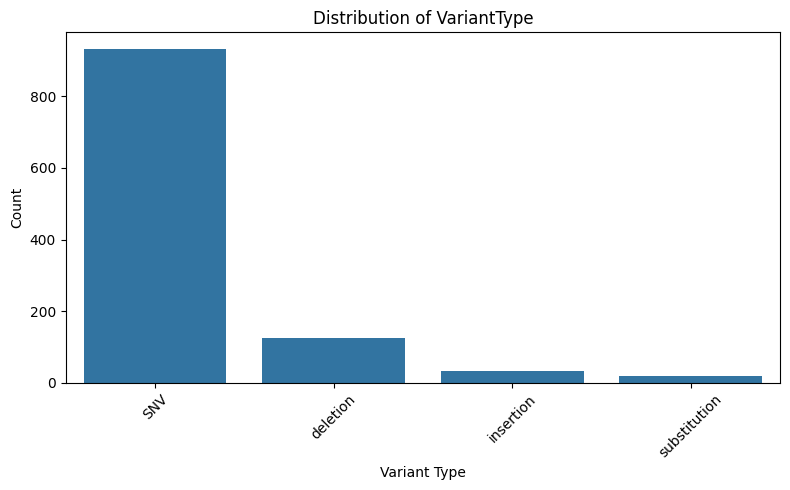

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

value_counts = merged_df['VariantType'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=value_counts.index, y=value_counts.values)
plt.title('Distribution of VariantType')
plt.xlabel('Variant Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
X = merged_df.drop(columns=['ModelID', 'VariantType'])
y = merged_df['VariantType'].astype('category').cat.codes

In [ ]:
## Oversampling
import os
os.environ["SCIPY_ARRAY_API"] = "1"

from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

# Assume X and y are defined:
# X = features (DataFrame or array)
# y = target labels (e.g., df['VariantType'])

# Oversample to balance classes
ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X, y)

# Check new class distribution
print("Before:", Counter(y))
print("After:", Counter(y_resampled))


Before: Counter({0: 932, 1: 125, 2: 33, 3: 18})
After: Counter({0: 932, 1: 932, 3: 932, 2: 932})


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# RANDOM FOREST SENZA OVERSAMPLING
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Step 4: Predict and evaluate
y_pred = clf.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.98      0.92       188
           1       1.00      0.08      0.15        24
           2       0.00      0.00      0.00         7
           3       1.00      0.33      0.50         3

    accuracy                           0.85       222
   macro avg       0.71      0.35      0.39       222
weighted avg       0.85      0.85      0.80       222

Confusion Matrix:
 [[185   0   3   0]
 [ 22   2   0   0]
 [  7   0   0   0]
 [  2   0   0   1]]


In [ ]:
# RANDOM FOREST CON OVERSAMPLING
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Step 4: Predict and evaluate
y_pred = clf.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99       207
           1       0.98      0.98      0.98       186
           2       0.99      1.00      1.00       178
           3       0.99      1.00      0.99       175

    accuracy                           0.99       746
   macro avg       0.99      0.99      0.99       746
weighted avg       0.99      0.99      0.99       746

Confusion Matrix:
 [[204   3   0   0]
 [  0 183   1   2]
 [  0   0 178   0]
 [  0   0   0 175]]
